# Fitting `ddm_normalt` with HSSM: the settings that work, and why

`ddm_normalt` is the drift-diffusion model with **Normal** trial-to-trial variability in
non-decision time: on each trial the actual non-decision time is drawn
$\tau \sim \mathrm{Normal}(t,\; s_t)$, so the observed reaction time is a decision
time plus that jittered offset. Note that here $s_t$ is the kernel's **standard
deviation**, where `ddm_st`'s $s_t$ is a uniform **half-width** (SD $= s_t/\sqrt{3}$) --
the same nominal $s_t$ means $\sqrt{3}\times$ more ndt dispersion in this model. Unlike the
uniform kernel, the Normal kernel is **unbounded**: there is no hard support edge at
$t - s_t$, and real density extends below it. The likelihood has no closed form, so we approximate it with a Likelihood Approximation Network
**(LAN)** a small neural network trained to reproduce the log-density, evaluated inside HSSM.

This notebook is a working reference for the settings that make that fit converge. Every
setting below was the cumulative result of many failed runs, and several of them
are non-obvious enough that the wrong value returns *plausible* numbers rather than an error.
Each one is stated with the alternative it beats and the evidence for the comparison.

**What you should see at the end:** a clean single-subject fit and a clean 12-subject
hierarchical fit: $\hat{R} \approx 1.00$, effective sample sizes in the hundreds to low
thousands, and essentially zero divergences — with convergence tables and trace plots for
single-subject parameters, hierarchical subject-level parameters, and hierarchical
group-level parameters.

---

### Jargon, once

| term | meaning |
|---|---|
| **LAN** | Likelihood Approximation Network. A neural net trained on KDE-estimated log-densities, standing in for a likelihood with no analytic form. |
| **$\hat{R}$ (r_hat)** | Gelman–Rubin statistic. Compares variance between MCMC chains to variance within them. $\approx 1.00$ means the chains agree; $> 1.01$ means they haven't converged to the same distribution. |
| **ESS** | Effective Sample Size. How many *independent* draws your correlated MCMC draws are worth. A few hundred is usually enough for posterior means. On complex hierarchical cases, sometimes nearing 100 is sufficient. |
| **divergence** | A step where the sampler's numerical integration blew up. Divergences mean the the sampler could not navigate the geometry and the draws are biased.  This is a very trustworthy warning NUTS provides. |
| **tree depth** | How many doubling steps NUTS took per draw. Hitting the cap (10) every draw means it never found a good place to stop.  This indicates badly-scaled or pathological geometry. |
| **BFMI** | Bayesian Fraction of Missing Information. Low values (< 0.3) mean the sampler is exploring the energy distribution poorly. |
| **link function** | A transform mapping a bounded parameter (e.g. $z \in [0.3, 0.7]$) onto the whole real line, so the sampler can move freely and never propose an invalid value. |
| **centered vs non-centered** | Two ways to write a hierarchical model. Centered puts subject effects on the natural scale; non-centered factors out the group scale. Which one samples better depends on how much data each subject has. |

> **How this notebook runs.** It needs the `labmate/st-networks` branch of HSSM
> (`pip install "hssm @ git+https://github.com/EItanm1999/HSSM.git@labmate/st-networks"`), which
> registers `ddm_normalt` and carries the guard fix described in §2, and the network file
> `ddm_normalt.onnx`, which is not yet on HuggingFace. By default the notebook looks for it in
> `/oscar/data/frankmj/st_networks`; set `ST_NETWORKS_DIR` to point elsewhere. Fits are cached
> in `_cache/` so a re-run does not resample. Sampling takes about half an hour on four cores.


## 1. Environment and provenance

Each setting is essential to making a trustworthy, functioning model. The network file, the `ssms` build, and the HSSM version together
determine what the likelihood actually is, so they are printed rather than assumed.

In [1]:
%matplotlib inline
import os, sys, warnings

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np, pandas as pd, arviz as az, matplotlib.pyplot as plt
import jax, hssm, ssms

# LANs are trained in float32; matching that here avoids
# precision mismatch between training and inference.
jax.config.update("jax_enable_x64", False)

print(f"hssm       {hssm.__version__}  (labmate/st-networks branch)")
print(f"ssms       {ssms.__version__}")
print(f"arviz      {az.__version__}")
print(f"jax        {jax.__version__}   x64={jax.config.jax_enable_x64}")

# `ddm_normalt` is a registered model in this HSSM branch. Once its network is published
# on HuggingFace, HSSM fetches it by name and the two lines below become unnecessary.
# Until then, point at a local copy: the lab folder by default, or set ST_NETWORKS_DIR.
MODEL = "ddm_normalt"
ST_NETWORKS_DIR = os.environ.get("ST_NETWORKS_DIR", "/oscar/data/frankmj/st_networks")
ONNX = os.path.join(ST_NETWORKS_DIR, f"{MODEL}.onnx")
if not os.path.isfile(ONNX):
    raise FileNotFoundError(f"{ONNX} not found. Set ST_NETWORKS_DIR to the folder holding {MODEL}.onnx.")
print(f"\nnetwork    {os.path.basename(ONNX)}  from ST_NETWORKS_DIR")


hssm       0.4.0  (labmate/st-networks branch)
ssms       0.13.2
arviz      1.3.0
jax        0.11.1   x64=False

network    ddm_normalt.onnx  from ST_NETWORKS_DIR


## 2. The admissibility guard, and why this branch is required

**This is the setting most likely to be missed, and the reason this notebook needs the branch rather than a released HSSM.**

HSSM applies an admissibility guard to every likelihood before returning it
(`hssm.distribution_utils.dist.ensure_positive_ndt`). In released HSSM (≤ 0.4.0) it reads

```python
pt.where(rt - t <= 1e-15, LOGP_LB, logp)
```

which floors any trial whose RT is at or below the non-decision time $t$. For a **fixed-$t$** DDM
that is correct — the support edge is $t$. For a model carrying $s_t$ it is wrong: probability
density extends below $t$, and the guard overwrites it with the log-probability floor no matter
what the likelihood returned. The call site assumes the non-decision-time parameter is always
named `t` and never checks whether the model also has `st`.

**This is easy to miss.** With `p_outlier > 0` the floored value is wrapped in the lapse
mixture, so affected trials emerge at $\log(0.05/20) = -5.99$ rather than at $-\infty$. Nothing
errors. The fit biases $t$ and looks like awkward geometry without any sign that it's the root cause.

The `ddm_normalt` registration in this branch ships `ndt_edge_width = 3.0` in its likelihood config, so `ensure_positive_ndt` (made `st`-aware by HSSM #1292) floors at $t - 3 s_t$, the Normal kernel's practical 3σ edge. Selecting the model string is enough; nothing to call.

Measured on this model, 12 subjects × 300 trials, the same data as §7:

| floor at | right for | $\hat{R}$ | min ESS | tree depth |
|---|---|---|---|---|
| $t$ (HSSM stock) | fixed-$t$ models only | 4.100 | 4 | 10.00, pegged |
| $t - s_t$ (compact-kernel floor) | the **Uniform** kernel — its support genuinely ends there | 3.390 | 4 | 10.00, pegged |
| $t - 3s_t$ (**this branch's default**) | the **Normal** kernel — its practical 3σ edge | **1.010** | **697** | 4.85 |
| none (no floor) | unbounded kernels, if `p_outlier > 0` is guaranteed | 1.010 | 606 | 4.79 |


In [2]:
# Helpers live next to this notebook (docs/tutorials/st_tutorial_helpers.py):
# explicit link-space priors and link-aware initial values, extracted from the
# LAN pipeline's canonical settings file.
sys.path.insert(0, os.getcwd())
from st_tutorial_helpers import make_manual_prior, make_initvals, summarize, trace_plot


## 3. Simulating data

### The seeding trap

`simulator(..., random_state=k)` does **not** fully determine the output for any model with
trial-to-trial variability. `ssms` seeds C's `srand` and a module-level NumPy generator, but the
variability distributions are SciPy partials, and `scipy.stats.uniform.rvs` without an explicit
`random_state` draws from NumPy's **legacy global** RNG — which `set_seed` never touches.

Two calls with the same `random_state` return different data (max $|\Delta \mathrm{rt}| \approx 0.62$
for `ddm_normalt`, worse than `ddm_st`'s 0.25 because the Normal kernel's tails are wider). Plain `ddm`, which has no variability distribution, *is* reproducible.

**So always call `np.random.seed()` as well.** Without it, "same data across arms" comparisons
are not actually holding the data fixed.

In [3]:
from ssms.basic_simulators.simulator import simulator

# True generating parameters. `st` is the SD of the Normal ndt kernel -- NOT a
# half-width like ddm_st's. The same nominal st therefore carries sqrt(3)x more
# ndt dispersion here than in ddm_st.
ST_TRUE      = 0.13
N_SUBJECTS   = 12
N_TRIALS     = 300

np.random.seed(0)                      # pins the ndt jitter (see above)
true_v = np.clip(np.random.normal(1.0, 0.30, N_SUBJECTS), -2.5, 2.5)
true_a = np.clip(np.random.normal(1.2, 0.20, N_SUBJECTS),  0.4, 2.4)
true_z = np.clip(np.random.normal(0.5, 0.05, N_SUBJECTS), 0.35, 0.65)
true_t = np.clip(np.random.normal(0.4, 0.05, N_SUBJECTS),  0.3, 0.55)

rows = []
for s in range(N_SUBJECTS):
    sd = simulator(model="ddm_normalt",
                   theta=[true_v[s], true_a[s], true_z[s], true_t[s], ST_TRUE],
                   n_samples=N_TRIALS, random_state=s)
    rt, ch = sd["rts"].flatten(), sd["choices"].flatten()
    ok = (rt > 0) & (rt != -999)       # -999 is the omission sentinel; the unbounded
    #    kernel CAN emit rt <= 0 (rare at this st; structural at the box corner)
    rows += [{"subject": f"s{s}", "rt": float(x), "response": int(y)}
             for x, y in zip(rt[ok], ch[ok])]

data_all = pd.DataFrame(rows)
data_one = data_all[data_all.subject == "s0"].reset_index(drop=True)

TRUTH = pd.DataFrame({"v": true_v, "a": true_a, "z": true_z, "t": true_t},
                     index=[f"s{i}" for i in range(N_SUBJECTS)])

print(f"all subjects : {len(data_all):5d} trials across {N_SUBJECTS} subjects")
print(f"subject s0   : {len(data_one):5d} trials")
print(f"\ntrue group means: v={true_v.mean():.3f}  a={true_a.mean():.3f}  "
      f"z={true_z.mean():.3f}  t={true_t.mean():.3f}  st={ST_TRUE}")
data_all.head()

all subjects :  3600 trials across 12 subjects
subject s0   :   300 trials

true group means: v=1.224  a=1.211  z=0.505  t=0.392  st=0.13


,subject,rt,response
0,s0,0.539462,1
1,s0,1.176892,1
2,s0,1.017345,1
3,s0,1.125099,1
4,s0,0.918756,1


## 4. Loading the likelihood network

The network takes a 7-vector — the five parameters in the order the model config declares them,
then RT and choice — and returns a scalar log-density. **Parameter order matters**: it
must match the column order the network was trained on. Get it wrong and nothing errors; you
just accidentally fit a different model.

In [4]:
import onnx

net = onnx.load(ONNX)
inp = net.graph.input[0]
dims = [d.dim_value or d.dim_param for d in inp.type.tensor_type.shape.dim]
print(f"network file   {os.path.basename(ONNX)}  ({os.path.getsize(ONNX) / 1024:.0f} KB)")
print(f"input          {inp.name} {dims}   (5 parameters + rt + choice)")
print(f"opset          {net.opset_import[0].version}")
# HSSM loads this file itself when it is passed as `loglik=`; nothing else to build.


network file   ddm_normalt.onnx  (83 KB)
input          input [7]   (5 parameters + rt + choice)
opset          17


### 4.1 Two small compatibility helpers

In this environment (`arviz` 0.23.4 / `xarray` 2026.4.0) HSSM returns `InferenceData` whose
groups are `DataTree` objects. Several `arviz` entry points -- `plot_trace`, `bfmi`, and
anything routed through `convert_to_inference_data` -- try to coerce what they are handed into
a numpy array and raise `TypeError: cannot directly convert a DataTree into a numpy array`.
The fix is one call: pull the group out as a plain `Dataset` with `.to_dataset()` before
handing it to `arviz`. This is an environment quirk, not a problem with the model.

The second helper caches each fit to disk. Sampling is the expensive part; a typo in a plot
should not cost you another run.

In [5]:
def post_of(idata):
    # Posterior group as a plain xarray Dataset (arviz/DataTree workaround).
    p = idata["posterior"]
    return p.to_dataset() if hasattr(p, "to_dataset") else p

def bfmi_of(idata):
    # BFMI per chain, computed from sample_stats energy directly.
    try:
        e = np.asarray(idata["sample_stats"]["energy"])
        if e.ndim == 1:
            e = e[None, :]
        return np.square(np.diff(e, axis=1)).mean(axis=1) / np.var(e, axis=1)
    except Exception:
        return None

def _group_names(idata):
    g = getattr(idata, "groups", None)
    if g is None:
        return []
    return list(g()) if callable(g) else list(g)

CACHE_DIR = "_cache"          # fits are cached here so re-running the notebook does not resample
os.makedirs(CACHE_DIR, exist_ok=True)

def sample_cached(model, path, **kw):
    # Sample, or reload a previous run of the same fit.
    path = os.path.join(CACHE_DIR, path)
    if os.path.exists(path):
        print(f"loading cached fit: {path}")
        return az.from_netcdf(path)
    idata = model.sample(**kw)
    for g in [None] + _group_names(idata):
        o = idata if g is None else idata[g]
        try:
            for k, v in list(o.attrs.items()):
                if not isinstance(v, (str, int, float, list, tuple, bytes)):
                    o.attrs[k] = str(v)
        except Exception:
            pass
    idata.to_netcdf(path)
    return idata

## 5. The settings, and what each one beats

### 5.1 Bounds — stay inside the trained box

A LAN only knows the region it was trained on. `ddm_normalt`'s training box matches `ddm_st`'s:
$v \in [-3, 3]$, $a \in [0.3, 2.5]$, $z \in [0.3, 0.7]$, $t \in [0.25, 2.25]$,
$s_t \in [10^{-3}, 0.25]$. The inference bounds below sit strictly inside it, so the sampler
never asks the network to extrapolate.

### 5.2 `p_outlier = 0.05` — set it and forget it

This is a lapse-rate mixture: each trial is modelled as coming from the DDM with probability
$1-p$, or from a flat "guess" distribution with probability $p$. **This is not a convergence
lever.** It was swept over $\{0, 0.05, 0.1, 0.2\}$ and 0.05 is already locally optimal —
mixing gets *worse* in either direction:

| `p_outlier` | 0.0 | **0.05** | 0.1 | 0.2 |
|---|---|---|---|---|
| $\hat{R}$ | 1.52 | **1.25** | 1.44 | 1.81 |
| ESS | 7 | **13** | 8 | 6 |

*(those numbers are from a one-subject `ddm_normalt` fit run before the guard correction;
the ranking is what matters, and 0.05 was re-confirmed as the default in the corrected runs.)* Setting it to 0 also disables a real safeguard and, with
`apply_skip()`, would remove the only floor keeping $-\infty$ out of the likelihood.

### 5.3 `st` stays a single shared scalar (population parameter)

Do **not** put `st` in `include`. Making it hierarchical is measured strictly harmful. It is
one number shared across subjects.

### 5.4 The three settings that must be used together

`0 + (1|subject)` **and** `noncentered=False` **and** `link_settings="log_logit"`. Any one of
these missing is a known-broken combination:

- **`0 + ...` without `noncentered=False`** — you get a non-identifiable `Intercept` sitting
  alongside centered subject effects.
- **centered without the link** — bounds get dropped without a warning, and the sampler can propose
  parameter values the network was never trained on.
- **the link without centering** — the composition stops being coherent.

The link is `gen_logit`, a generalised logistic mapping each bounded parameter onto the real
line. It is what lets NUTS move freely without ever proposing an invalid value.

### 5.5 Priors: set them explicitly

`prior_settings="safe"` auto-fills any term that has no manually-supplied prior. Supplying one
for **every** `include` entry makes that auto-fill branch unreachable by construction, rather
than something to audit for sporatic failure.

**Under a link, use the link-space prior shape, not the HDDM-shaped one.** Substituting a
Gamma or Beta prior while a link is active produces immediate frozen-chain collapse: step size
$1.18 \times 10^{-38}$ from the first iteration, tree depth 1, 100% divergence. The working
explanation: a Gamma/Beta prior's own support constrains the *same raw variable* that
`gen_logit`'s sigmoid is then applied to, so the result can only ever land in the upper half of
the sigmoid's range. It's a double constraint, not a free choice of shape.

### 5.6 `mu_sigma` — one setting that differs between the two fits

`make_manual_prior(..., mu_sigma=...)` sets the width of the group-mean hyperprior in link space.

- **Single subject: `mu_sigma=2.0`.** At N=1 the default 0.25 is narrow enough to dominate a
  weak likelihood, pulling estimates toward the prior's own centre regardless of the true data.
  That looks like non-identifiability but isn't.
- **Hierarchical N=12 on `ddm_normalt`: also `mu_sigma=2.0`.** This is the setting §7 actually
  uses. With the guard corrected (§2), this model behaves exactly like `ddm_st` here: under the
  default 0.25 the group-level `v` and `t` locations get pulled toward the midpoint of their own
  bounds (measured on this exact setup: `v` group mean 0.82 vs true 1.22, `t` 0.63 vs true 0.39,
  with the `t` group sigma doubling to absorb it) while every per-subject estimate still looks
  fine.
- **A caution about the historical record.** An older result claimed widening *destabilised*
  `ddm_normalt` at N=12 ($\hat{R}$ 1.02 → 1.55). That was measured **through the stock guard**
  (§2) and does not survive the correction — with the guard fixed, `mu_sigma=2.0` gives
  $\hat{R}$ 1.010 here. Do not re-inherit it.

**This is still a per-model decision, not a blanket "wider is safer."** §7.5 and §7.6 run both
settings on `ddm_normalt` and compare convergence *and* recovery, which is the only way to
settle it for a given model.

### 5.7 `initval_jitter=0` — pass it explicitly

HSSM's `initval_jitter` defaults to $\varepsilon = 0.01$, and it is a **separate mechanism**
from the sampler-level jitter HSSM disables automatically. It is not off by default. Pass 0
explicitly or your set starting values get perturbed.

### 5.8 The `t` starting value — 0.30, in link space

HSSM's default starting value for `t` is 0.025, which is **outside** this model's `t` bounds and
freezes sampling outright. Use 0.30.

Under a link, initial values must be given in **link space**. Passing a natural-scale number
raw maps to the wrong point. `make_initvals()` handles the transform and picks the
right key name for whichever formula you used.

In [6]:
# st's lower bound is 0.01, not the 0.001 edge of the trained box. Below 0.01
# the network places its maximum on the bound itself, where the exact likelihood
# has an interior maximum, and the gradient there points INTO the bound - chains
# trap and st collapses while every mixing diagnostic still looks clean.
BOUNDS = {"v": (-2.0, 2.0), "a": (0.5, 2.0), "z": (0.35, 0.65),
          "t": (0.25, 1.5), "st": (0.01, 0.25)}
P_OUTLIER = 0.05
T_INIT    = 0.30
HIER      = ["v", "a", "z", "t"]        # note: `st` intentionally absent

# The registered model carries the network's training box as its bounds; the narrower
# box above is passed through `model_config` so it overrides those defaults.

SAMPLE_KWARGS = dict(sampler="numpyro", chains=4, cores=1,
                     draws=1000, tune=1000, target_accept=0.8,
                     random_seed=0, idata_kwargs=dict(log_likelihood=False))
print("configuration ready")

configuration ready


## 6. Fit 1 — single subject

No hierarchy: five parameters, one subject, 300 trials. This is the simplest working configuration, and it is worth confirming it does before adding structure on top.

Note `mu_sigma=2.0` here, per §5.6.

In [7]:
model_single = hssm.HSSM(
    data=data_one,
    model=MODEL,
    model_config={"bounds": BOUNDS},
    loglik=ONNX,
    loglik_kind="approx_differentiable",
    p_outlier=P_OUTLIER,
    prior_settings="safe",
    link_settings="log_logit",
    initval_jitter=0,                      # NOT off by default -- see 5.7
)

initvals_single = make_initvals(model_single, t_natural=T_INIT, bounds=BOUNDS["t"])
idata_single = sample_cached(model_single, "fit_single.nc",
                             initvals=initvals_single, **SAMPLE_KWARGS)
print("single-subject sampling complete")

Model initialized successfully.


  [hssm_run_defaults] initval t = 0.3000 natural
loading cached fit: _cache/fit_single.nc


single-subject sampling complete


### 6.1 How to read the diagnostics

**Judge on divergences, BFMI and tree depth. $\hat{R}$ alone is not sufficient.** In this model family
$\hat{R}$ carries roughly $\pm 0.48$ of run-to-run noise from just the seed, and it can be
*anti*-correlated with correctness: four chains all stuck against the same boundary agree with
each other and produce a low $\hat{R}$. Divergences replicate tightly and tree depth
separates the failure modes cleanly.

In [8]:
def diagnostics(idata, label):
    summ = summarize(post_of(idata))
    ss   = idata["sample_stats"]
    div  = float(np.asarray(ss["diverging"]).mean()) * 100
    td   = np.asarray(ss["tree_depth"])
    b    = bfmi_of(idata)
    bfmi_s = "n/a" if b is None else f"{b.min():.2f}-{b.max():.2f}"
    out = pd.DataFrame([{
        "fit": label,
        "worst r_hat": round(float(summ["r_hat"].max()), 3),
        "min ESS bulk": int(summ["ess_bulk"].min()),
        "min ESS tail": int(summ["ess_tail"].min()),
        "divergences %": round(div, 2),
        "mean tree depth": round(float(td.mean()), 2),
        "% at max depth": round(100 * float((td == td.max()).mean()), 2),
        "BFMI range": bfmi_s,
    }])
    return summ, out

summ_single, diag_single = diagnostics(idata_single, "single subject")
diag_single

,fit,worst r_hat,min ESS bulk,min ESS tail,divergences %,mean tree depth,% at max depth,BFMI range
0,single subject,1.003,825,796,0.0,4.28,0.12,0.63-0.78


In [9]:
# Parameter recovery against the values that generated s0.
truth_s0 = dict(TRUTH.loc["s0"]); truth_s0["st"] = ST_TRUE
rec = summ_single.loc[[p for p in ["v", "a", "z", "t", "st"] if p in summ_single.index]].copy()
rec.insert(0, "true", [truth_s0[p] for p in rec.index])
rec["bias"] = rec["mean"] - rec["true"]
rec["in 94% HDI"] = [(lo <= truth_s0[p] <= hi) for p, lo, hi
                     in zip(rec.index, rec["hdi_3%"], rec["hdi_97%"])]
rec[["true", "mean", "sd", "hdi_3%", "hdi_97%", "bias", "in 94% HDI", "ess_bulk", "r_hat"]]

,true,mean,sd,hdi_3%,hdi_97%,bias,in 94% HDI,ess_bulk,r_hat
v,1.529216,1.65,0.159,1.371027,1.948621,0.121373,True,928,1.00
a,1.352208,1.3,0.16,1.059162,1.622061,-0.050973,True,923,1.00
z,0.613488,0.597,0.042,0.519108,0.649973,-0.016008,True,1164,1.00
t,0.461515,0.477,0.059,0.364758,0.581196,0.015508,True,825,1.00
st,0.13,0.119,0.021,0.079997,0.157186,-0.01061,True,1298,1.00


### 6.2 Trace — single-subject parameters

Read these as: left panel, four posterior densities that should sit on top of one another;
right panel, four caterpillars that should look like flat noise with no drift, no sticking,
and no visible chain separation.

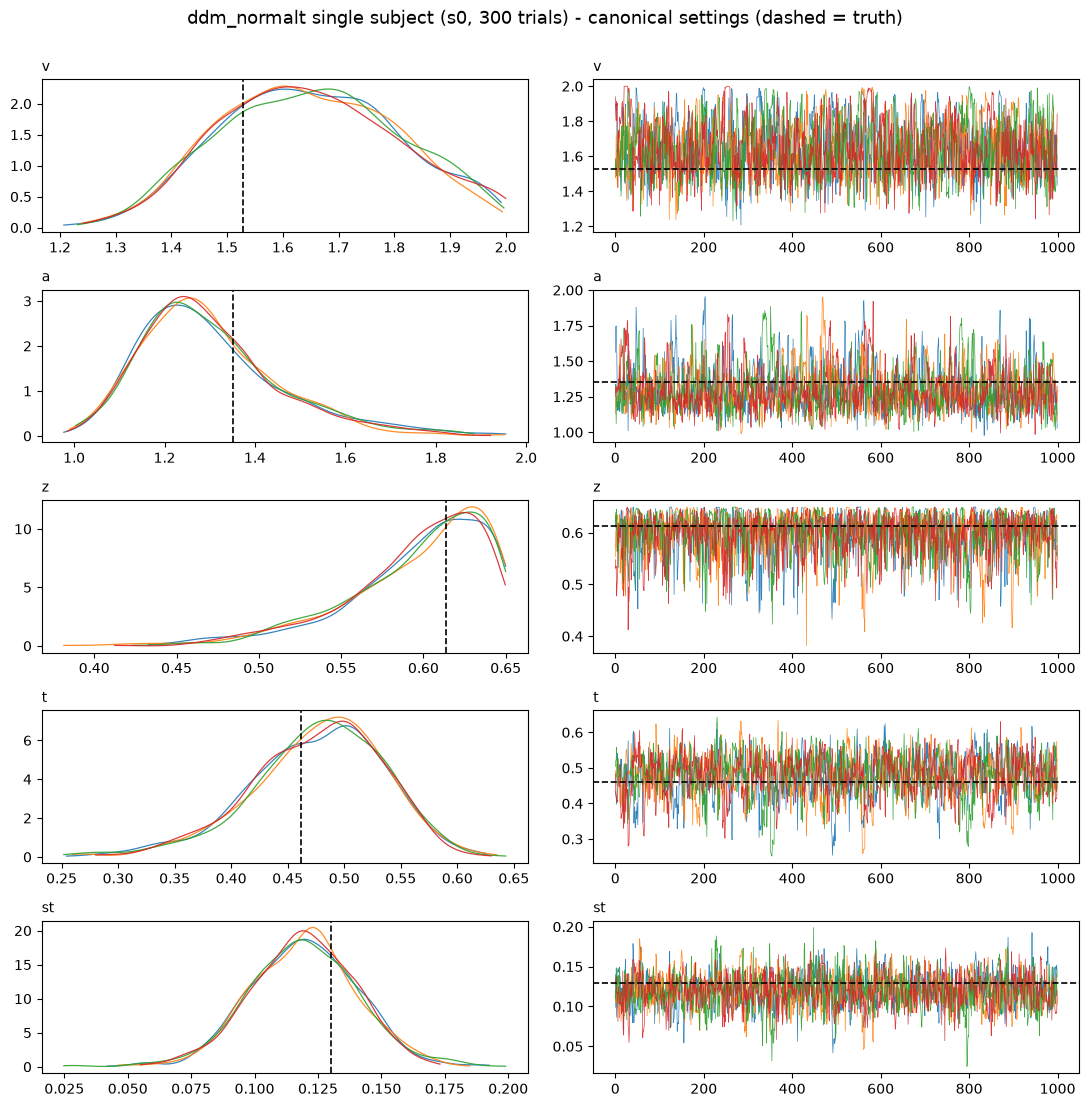

array([[<Axes: title={'left': 'v'}>, <Axes: title={'left': 'v'}>],
       [<Axes: title={'left': 'a'}>, <Axes: title={'left': 'a'}>],
       [<Axes: title={'left': 'z'}>, <Axes: title={'left': 'z'}>],
       [<Axes: title={'left': 't'}>, <Axes: title={'left': 't'}>],
       [<Axes: title={'left': 'st'}>, <Axes: title={'left': 'st'}>]],
      dtype=object)

In [10]:
# dashed line = the value that generated s0's data (natural scale)
truth_s0_line = dict(TRUTH.loc["s0"]); truth_s0_line["st"] = ST_TRUE
trace_plot(post_of(idata_single), ["v", "a", "z", "t", "st"], truth=truth_s0_line,
           title="ddm_normalt single subject (s0, 300 trials) - canonical settings (dashed = truth)", figsize=(11, 11))


## 7. Fit 2 — 12-subject hierarchical

Now the structure. Each of `v`, `a`, `z`, `t` gets `~ 0 + (1|subject)`: a group mean and a group
standard deviation, plus one value per subject. `st` stays a single shared scalar (§5.3).

Three things change from the single-subject fit, and all three are deliberate:

1. `include=[...]` with an explicit prior on every term (§5.5)
2. `noncentered=False`, paired with the `0 + ` formula and the link (§5.4)
3. `mu_sigma = 2.0`, the same as the single-subject fit — **not** HSSM's default of 0.25 (§5.6)

That third point is the one people get wrong, so it is worth stating plainly here: this fit uses
the **widened** group-mean hyperprior. §7.5 runs the default 0.25 alongside it and §7.6 shows
what the default does to group-level recovery. Everything else about the two runs is identical.

In [11]:
include = [{"name": p,
            "formula": f"{p} ~ 0 + (1|subject)",
            "prior": {"1|subject": make_manual_prior(p, linked=True, mu_sigma=2.0)}}
           for p in HIER]

model_hier = hssm.HSSM(
    data=data_all,
    model=MODEL,
    model_config={"bounds": BOUNDS},
    loglik=ONNX,
    loglik_kind="approx_differentiable",
    p_outlier=P_OUTLIER,
    include=include,
    prior_settings="safe",
    noncentered=False,                     # paired with `0 + ` and the link
    link_settings="log_logit",
    initval_jitter=0,
)

initvals_hier = make_initvals(model_hier, t_natural=T_INIT, bounds=BOUNDS["t"])
idata_hier = sample_cached(model_hier, "fit_hier_musigma2.nc",
                           initvals=initvals_hier, **SAMPLE_KWARGS)
print("hierarchical sampling complete")

  [hssm_run_defaults] manual prior for 'v' (linked=True): Normal(mu: Normal(mu: 0.0, sigma: 2.0), sigma: Weibull(alpha: 1.5, beta: 0.3))
  [hssm_run_defaults] manual prior for 'a' (linked=True): Normal(mu: Normal(mu: 0.0, sigma: 2.0), sigma: Weibull(alpha: 1.5, beta: 0.3))
  [hssm_run_defaults] manual prior for 'z' (linked=True): Normal(mu: Normal(mu: 0.0, sigma: 2.0), sigma: Weibull(alpha: 1.5, beta: 0.3))
  [hssm_run_defaults] manual prior for 't' (linked=True): Normal(mu: Normal(mu: 0.0, sigma: 2.0), sigma: Weibull(alpha: 1.5, beta: 0.3))


Model initialized successfully.


  [hssm_run_defaults] initval t_1|subject_mu = -3.1781 link space (== 0.3 natural)


NUTS[numpyro]: [st, v_1|subject_mu, v_1|subject_sigma, v_1|subject, a_1|subject_mu, a_1|subject_sigma, a_1|subject, z_1|subject_mu, z_1|subject_sigma, z_1|subject, t_1|subject_mu, t_1|subject_sigma, t_1|subject]


  0%|          | 0/2000 [00:00<?, ?it/s]

...

sample:  90%|█████████ | 1800/2000 [01:32<00:10, 18.64it/s, 15 steps of size 1.81e-01. acc. prob=0.89]

sample:  95%|█████████▌| 1900/2000 [01:37<00:05, 18.63it/s, 31 steps of size 1.81e-01. acc. prob=0.89]

sample: 100%|██████████| 2000/2000 [01:43<00:00, 18.57it/s, 31 steps of size 1.81e-01. acc. prob=0.89]

sample: 100%|██████████| 2000/2000 [01:43<00:00, 19.40it/s, 31 steps of size 1.81e-01. acc. prob=0.89]

hierarchical sampling complete


### 7.1 Convergence table

Two rows are reported deliberately.

**Worst-over-all-parameters** is the reliable engineering number: it includes all 48 subject-level
effects and the group scales, and it is what you should check before trusting anything.

**Population-level only** is the convention HSSM's own shipped tutorials report — their
flagship hierarchical workflow summarises with `var_names=["~participant_id"]`, where the `~`
is an *exclusion*, so per-subject effects and group sigmas never appear. Their accepted result
on that basis is ESS 89–311 at $\hat{R}$ 1.01. Both numbers are given here so this fit can be
compared against either convention without anyone having to guess which was used.

In [12]:
summ_hier, diag_hier = diagnostics(idata_hier, "hierarchical (all params)")

post_h = post_of(idata_hier)
group_vars = [v for v in post_h.data_vars
              if v.endswith("_mu") or v.endswith("_sigma") or v == "st"]
summ_pop = summarize(post_h, var_names=group_vars)
diag_pop = pd.DataFrame([{
    "fit": "hierarchical (population-level only)",
    "worst r_hat": round(float(summ_pop["r_hat"].max()), 3),
    "min ESS bulk": int(summ_pop["ess_bulk"].min()),
    "min ESS tail": int(summ_pop["ess_tail"].min()),
    "divergences %": diag_hier["divergences %"].iloc[0],
    "mean tree depth": diag_hier["mean tree depth"].iloc[0],
    "% at max depth": diag_hier["% at max depth"].iloc[0],
    "BFMI range": diag_hier["BFMI range"].iloc[0],
}])

pd.concat([diag_single, diag_hier, diag_pop], ignore_index=True)

,fit,worst r_hat,min ESS bulk,min ESS tail,divergences %,mean tree depth,% at max depth,BFMI range
0,single subject,1.003,825,796,0.0,4.28,0.12,0.63-0.78
1,hierarchical (all params),1.004,1667,1872,0.0,4.79,2.00,0.88-0.95
2,hierarchical (population-level only),1.002,1667,1872,0.0,4.79,2.00,0.88-0.95


### 7.2 Trace — hierarchical **group-level** parameters

The group mean and group SD for each parameter, plus the shared `st`. These are the parameters
you would report in a paper.

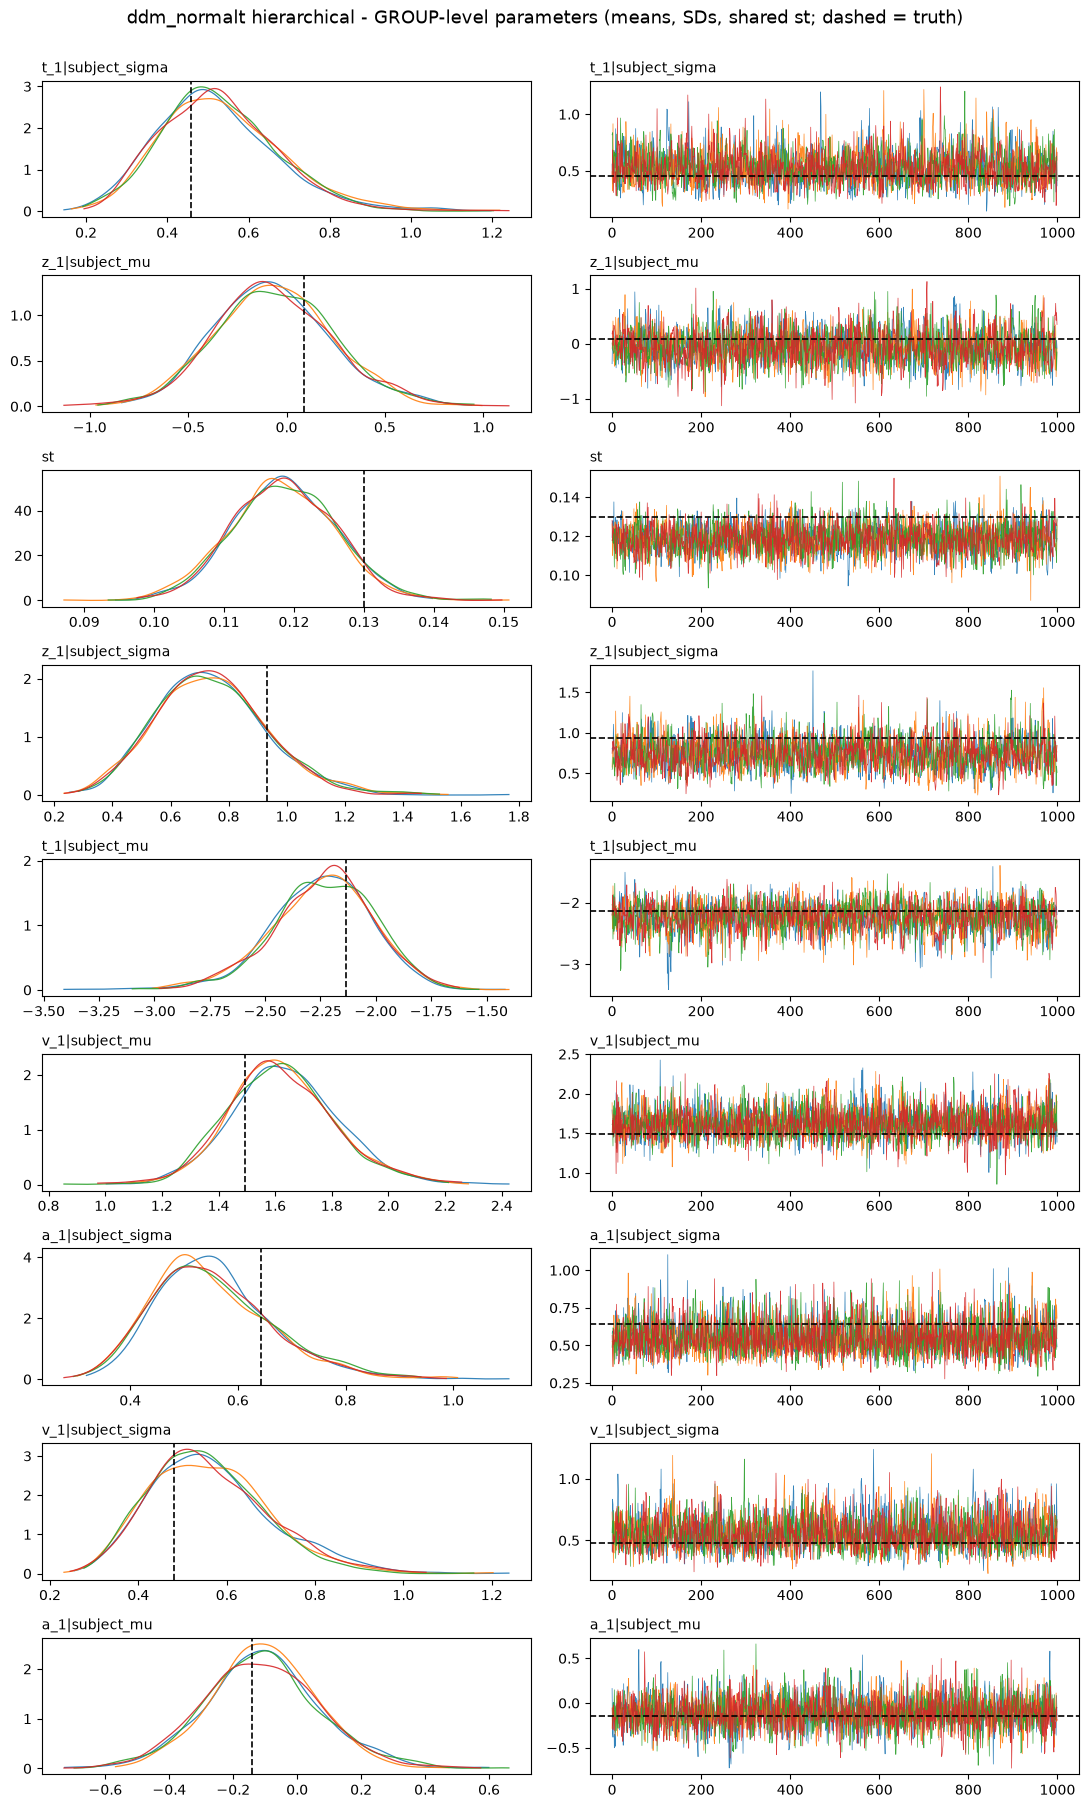

array([[<Axes: title={'left': 't_1|subject_sigma'}>,
        <Axes: title={'left': 't_1|subject_sigma'}>],
       [<Axes: title={'left': 'z_1|subject_mu'}>,
        <Axes: title={'left': 'z_1|subject_mu'}>],
       [<Axes: title={'left': 'st'}>, <Axes: title={'left': 'st'}>],
       [<Axes: title={'left': 'z_1|subject_sigma'}>,
        <Axes: title={'left': 'z_1|subject_sigma'}>],
       [<Axes: title={'left': 't_1|subject_mu'}>,
        <Axes: title={'left': 't_1|subject_mu'}>],
       [<Axes: title={'left': 'v_1|subject_mu'}>,
        <Axes: title={'left': 'v_1|subject_mu'}>],
       [<Axes: title={'left': 'a_1|subject_sigma'}>,
        <Axes: title={'left': 'a_1|subject_sigma'}>],
       [<Axes: title={'left': 'v_1|subject_sigma'}>,
        <Axes: title={'left': 'v_1|subject_sigma'}>],
       [<Axes: title={'left': 'a_1|subject_mu'}>,
        <Axes: title={'left': 'a_1|subject_mu'}>]], dtype=object)

In [13]:
# dashed line = truth, in the space each panel is drawn in. Group panels live in
# LINK space: mu's truth is the mean of the link-transformed true subject values,
# sigma's truth is their SD (see 7.4 for why natural-scale comparison is subtler).
def _fwd_link(x, p):
    lo, hi = BOUNDS[p]
    return np.log((np.asarray(x, dtype=float) - lo) / (hi - np.asarray(x, dtype=float)))
truth_line = {"st": ST_TRUE}
for p in HIER:
    lk = _fwd_link(TRUTH[p].values, p)
    truth_line[f"{p}_1|subject_mu"] = lk.mean()
    truth_line[f"{p}_1|subject_sigma"] = lk.std(ddof=0)
trace_plot(post_h, group_vars, truth=truth_line,
           title="ddm_normalt hierarchical - GROUP-level parameters (means, SDs, shared st; dashed = truth)")


### 7.3 Trace — hierarchical **subject-level** parameters

The per-subject effects. There are 12 of these per parameter, so they are drawn `compact=True`
— one panel per parameter with all 12 subjects overlaid. Look for any single subject whose
chains separate or stick; that is usually the one with the least informative data.

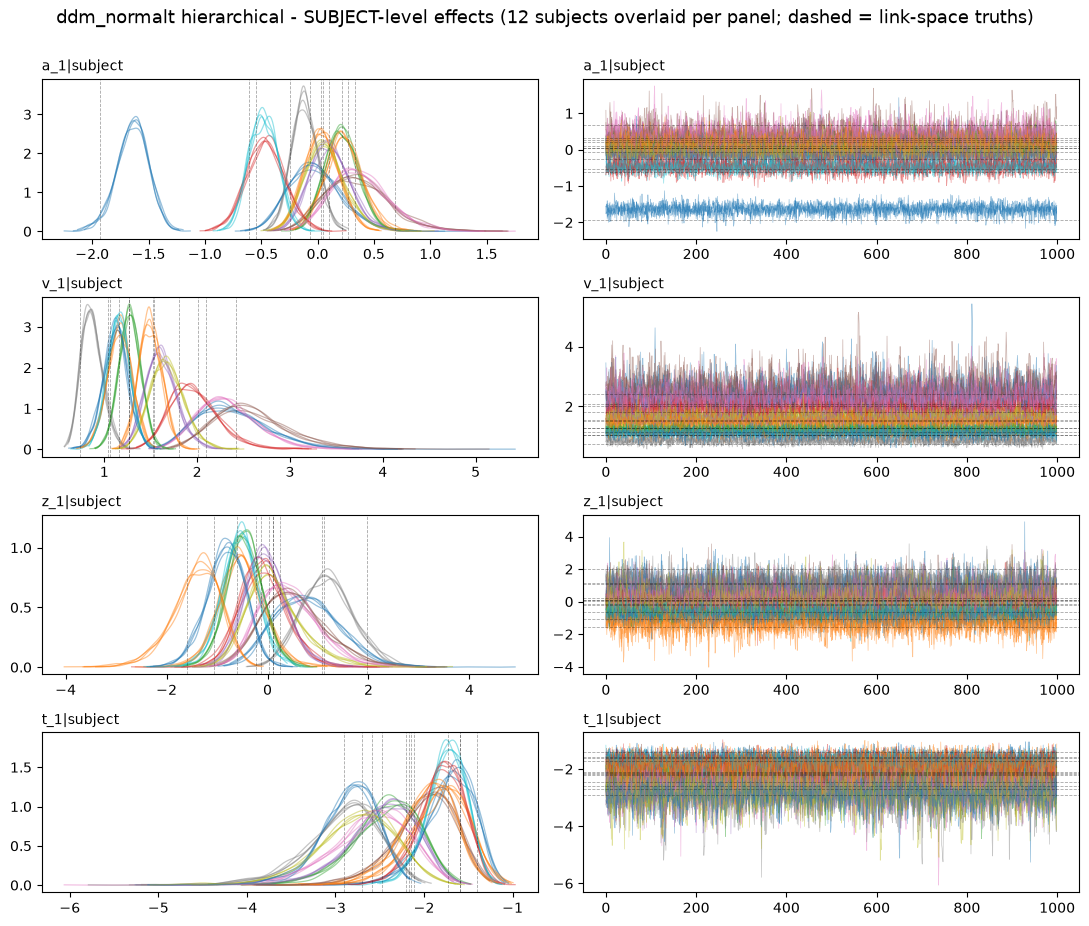

array([[<Axes: title={'left': 'a_1|subject'}>,
        <Axes: title={'left': 'a_1|subject'}>],
       [<Axes: title={'left': 'v_1|subject'}>,
        <Axes: title={'left': 'v_1|subject'}>],
       [<Axes: title={'left': 'z_1|subject'}>,
        <Axes: title={'left': 'z_1|subject'}>],
       [<Axes: title={'left': 't_1|subject'}>,
        <Axes: title={'left': 't_1|subject'}>]], dtype=object)

In [14]:
subj_vars = [v for v in post_h.data_vars
             if v.endswith("|subject") and not v.endswith(("_mu", "_sigma"))]
# light dashed lines = the 12 link-space true subject values per parameter
def _fwd_link(x, p):
    lo, hi = BOUNDS[p]
    return np.log((np.asarray(x, dtype=float) - lo) / (hi - np.asarray(x, dtype=float)))
subj_truth = {name: _fwd_link(TRUTH[name.split("_1|subject")[0]].values, name.split("_1|subject")[0])
              for name in subj_vars}
trace_plot(post_h, subj_vars, truth=subj_truth,
           title="ddm_normalt hierarchical - SUBJECT-level effects (12 subjects overlaid per panel; dashed = link-space truths)", figsize=(11, 2.3 * len(subj_vars)))


### 7.4 Recovery, and how to read it without falling into common pitfalls

Clean convergence by itself does not mean correct estimates, so check recovery separately.

**Read both tables, and know what each one can hide.** The group-level parameter
`v_1|subject_mu` lives in *link* space, and `inv_link` is nonlinear, so `inv_link(group mean)`
is the **median** of the natural-scale subject distribution, not its mean. Comparing it against
the arithmetic mean of the true subject values mixes a transform artefact into whatever real
error is present, so the naive group table is not a clean read on its own. §7.6 redoes the
comparison correctly; transform each subject's draws to the natural scale first, then compare.
Both tables are shown here so the discrepancy is visible rather than hidden.

The per-subject table has the opposite blind spot, and it matters more than it sounds. Subject
effects are pinned down by each subject's own 300 trials, so they can look entirely healthy while
the group-level parameters describing them are badly wrong — which is exactly what happens under
the default prior in §7.5. **A table of subject estimates alone would not have caught it.**

For reference, the corrected-guard `ddm_normalt` baseline on this exact setup
(`archive/37_postfix_reruns`, 12 subjects × 300 trials, recovery paired by label) is mean bias
`v` +0.064, `a` +0.007, `z` -0.009, `t` -0.009, with per-subject correlations of +0.98 (`v`),
+0.95 (`a`), +0.84 (`z`), +0.88 (`t`) and 11/12 coverage on all four. The per-subject table
below should land in that neighbourhood.

#### Group-level

Link-space estimates transformed back to the natural scale and compared against the values that
generated the data.

In [15]:
def inv_link(x, p):
    lo, hi = BOUNDS[p]
    return lo + (hi - lo) / (1 + np.exp(-x))

recovery = []
for p in HIER:
    key = f"{p}_1|subject_mu"
    if key not in post_h:
        continue
    draws = inv_link(np.asarray(post_h[key]), p)
    recovery.append({"param": p, "true group mean": TRUTH[p].mean(),
                     "estimated": draws.mean(),
                     "bias": draws.mean() - TRUTH[p].mean(),
                     "hdi 3%": np.percentile(draws, 3),
                     "hdi 97%": np.percentile(draws, 97)})
if "st" in post_h:
    d = np.asarray(post_h["st"])
    recovery.append({"param": "st", "true group mean": ST_TRUE, "estimated": d.mean(),
                     "bias": d.mean() - ST_TRUE,
                     "hdi 3%": np.percentile(d, 3), "hdi 97%": np.percentile(d, 97)})

rec_df = pd.DataFrame(recovery).set_index("param")
rec_df["true in HDI"] = [(lo <= t <= hi) for t, lo, hi
                         in zip(rec_df["true group mean"], rec_df["hdi 3%"], rec_df["hdi 97%"])]
rec_df.round(4)

,true group mean,estimated,bias,hdi 3%,hdi 97%,true in HDI
param,,,,,,
v,1.2245,1.3363,0.1119,1.1450,1.5266,True
a,1.2105,1.2099,-0.0006,1.0906,1.3394,True
z,0.5048,0.4954,-0.0094,0.4566,0.5392,True
t,0.3921,0.3725,-0.0196,0.3286,0.4219,True
st,0.1300,0.1186,-0.0114,0.1046,0.1324,True


#### Per-subject

In [16]:
def per_subject_recovery(post, label):
    # NOTE: subject coordinates come back from bambi in ALPHABETICAL order
    # (s0, s1, s10, s11, s2, ...), while TRUTH is indexed s0..s11 numerically.
    # Pairing them positionally (e.g. via .reshape(-1, n_subjects)) mispairs
    # 10 of 12 subjects. Mean bias survives that (a permutation does not move a
    # mean) but coverage and any correlation with truth do not -- so subjects
    # are selected BY LABEL here.
    out = []
    for p in HIER:
        key = f"{p}_1|subject"
        if key not in post:
            continue
        da  = post[key]
        dim = [c for c in da.dims if "factor" in c][0]
        est, lo, hi = [], [], []
        for i in range(N_SUBJECTS):
            nat = inv_link(np.asarray(da.sel({dim: f"s{i}"}).values), p)
            est.append(nat.mean())
            lo.append(np.percentile(nat, 3))
            hi.append(np.percentile(nat, 97))
        est, lo, hi = map(np.asarray, (est, lo, hi))
        tru = TRUTH[p].values
        out.append({"param": p, "mean bias": (est - tru).mean(),
                    "mean |bias|": np.abs(est - tru).mean(),
                    "coverage (of 12)": int(((lo <= tru) & (tru <= hi)).sum())})
    df = pd.DataFrame(out).set_index("param")
    df.columns = pd.MultiIndex.from_product([[label], df.columns])
    return df

per_subject_recovery(post_h, "mu_sigma = 2.0 (used above)").round(4)


mu_sigma = 2.0 (used above)                             
                        mean bias mean |bias| coverage (of 12)
param                                                         
v                          0.0651      0.0774               12
a                          0.0075      0.0514               11
z                         -0.0096      0.0259               11
t                         -0.0104      0.0246               11

### 7.5 What the default `mu_sigma = 0.25` does instead

§7 used the widened hyperprior. This section runs HSSM's default 0.25 with **everything else held
identical** — same data, same formula, same link, same initial values, same sampler settings — so
the only difference is the width of the group-mean hyperprior in link space.

Read the convergence table first and notice how little it tells you: the default arm converges
perfectly well by every standard diagnostic. Then read §7.6, where the group-level recovery
separates the two arms decisively.

A historical caution: an older result claimed widening *destabilised* this very model at N=12
($\hat{R}$ 1.02 → 1.55, min ESS 610 → 7). That number was measured **through the stock
admissibility guard** (§2) — the moving cliff, not the prior, was the instability — and it does
not survive the guard correction. It is retained here only so nobody re-inherits it. The
decision is still per-model: measure, do not assume.

In [17]:
include_narrow = [{"name": p,
                 "formula": f"{p} ~ 0 + (1|subject)",
                 "prior": {"1|subject": make_manual_prior(p, linked=True)}}   # DEFAULT mu_sigma = 0.25
                for p in HIER]

model_narrow = hssm.HSSM(
    data=data_all, model=MODEL, model_config={"bounds": BOUNDS},
    loglik=ONNX, loglik_kind="approx_differentiable",
    p_outlier=P_OUTLIER, include=include_narrow, prior_settings="safe",
    noncentered=False, link_settings="log_logit", initval_jitter=0)

initvals_narrow = make_initvals(model_narrow, t_natural=T_INIT, bounds=BOUNDS["t"])
idata_narrow = sample_cached(model_narrow, "fit_hier_musigma025.nc",
                             initvals=initvals_narrow, **SAMPLE_KWARGS)
post_n = post_of(idata_narrow)
_, diag_narrow = diagnostics(idata_narrow, "hierarchical (mu_sigma=0.25, DEFAULT)")
print("default-prior comparison sampling complete")

  [hssm_run_defaults] manual prior for 'v' (linked=True): Normal(mu: Normal(mu: 0.0, sigma: 0.25), sigma: Weibull(alpha: 1.5, beta: 0.3))
  [hssm_run_defaults] manual prior for 'a' (linked=True): Normal(mu: Normal(mu: 0.0, sigma: 0.25), sigma: Weibull(alpha: 1.5, beta: 0.3))
  [hssm_run_defaults] manual prior for 'z' (linked=True): Normal(mu: Normal(mu: 0.0, sigma: 0.25), sigma: Weibull(alpha: 1.5, beta: 0.3))
  [hssm_run_defaults] manual prior for 't' (linked=True): Normal(mu: Normal(mu: 0.0, sigma: 0.25), sigma: Weibull(alpha: 1.5, beta: 0.3))


Model initialized successfully.


  [hssm_run_defaults] initval t_1|subject_mu = -3.1781 link space (== 0.3 natural)


NUTS[numpyro]: [st, v_1|subject_mu, v_1|subject_sigma, v_1|subject, a_1|subject_mu, a_1|subject_sigma, a_1|subject, z_1|subject_mu, z_1|subject_sigma, z_1|subject, t_1|subject_mu, t_1|subject_sigma, t_1|subject]


  0%|          | 0/2000 [00:00<?, ?it/s]

...

sample:  90%|█████████ | 1800/2000 [01:37<00:10, 18.72it/s, 31 steps of size 1.75e-01. acc. prob=0.89]

sample:  95%|█████████▌| 1900/2000 [01:42<00:05, 18.31it/s, 15 steps of size 1.75e-01. acc. prob=0.89]

sample: 100%|██████████| 2000/2000 [01:48<00:00, 18.37it/s, 15 steps of size 1.75e-01. acc. prob=0.89]

sample: 100%|██████████| 2000/2000 [01:48<00:00, 18.49it/s, 15 steps of size 1.75e-01. acc. prob=0.89]

default-prior comparison sampling complete


In [18]:
print("CONVERGENCE\n")
display(pd.concat([diag_hier, diag_narrow], ignore_index=True))

print("\nPER-SUBJECT RECOVERY\n")
display(pd.concat([per_subject_recovery(post_h, "mu_sigma = 2.0  (used above)"),
                   per_subject_recovery(post_n, "mu_sigma = 0.25 (default)")], axis=1).round(4))

CONVERGENCE



,fit,worst r_hat,min ESS bulk,min ESS tail,divergences %,mean tree depth,% at max depth,BFMI range
0,hierarchical (all params),1.004,1667,1872,0.0,4.79,2.0,0.88-0.95
1,"hierarchical (mu_sigma=0.25, DEFAULT)",1.004,2147,2103,0.0,4.92,0.9,0.81-0.99



PER-SUBJECT RECOVERY



mu_sigma = 2.0  (used above)                               \
                         mean bias mean |bias| coverage (of 12)   
param                                                             
v                           0.0651      0.0774               12   
a                           0.0075      0.0514               11   
z                          -0.0096      0.0259               11   
t                          -0.0104      0.0246               11   

      mu_sigma = 0.25 (default)                               
                      mean bias mean |bias| coverage (of 12)  
param                                                         
v                        0.0339      0.0576               12  
a                       -0.0114      0.0492               11  
z                        0.0025      0.0264               11  
t                        0.0099      0.0288               11

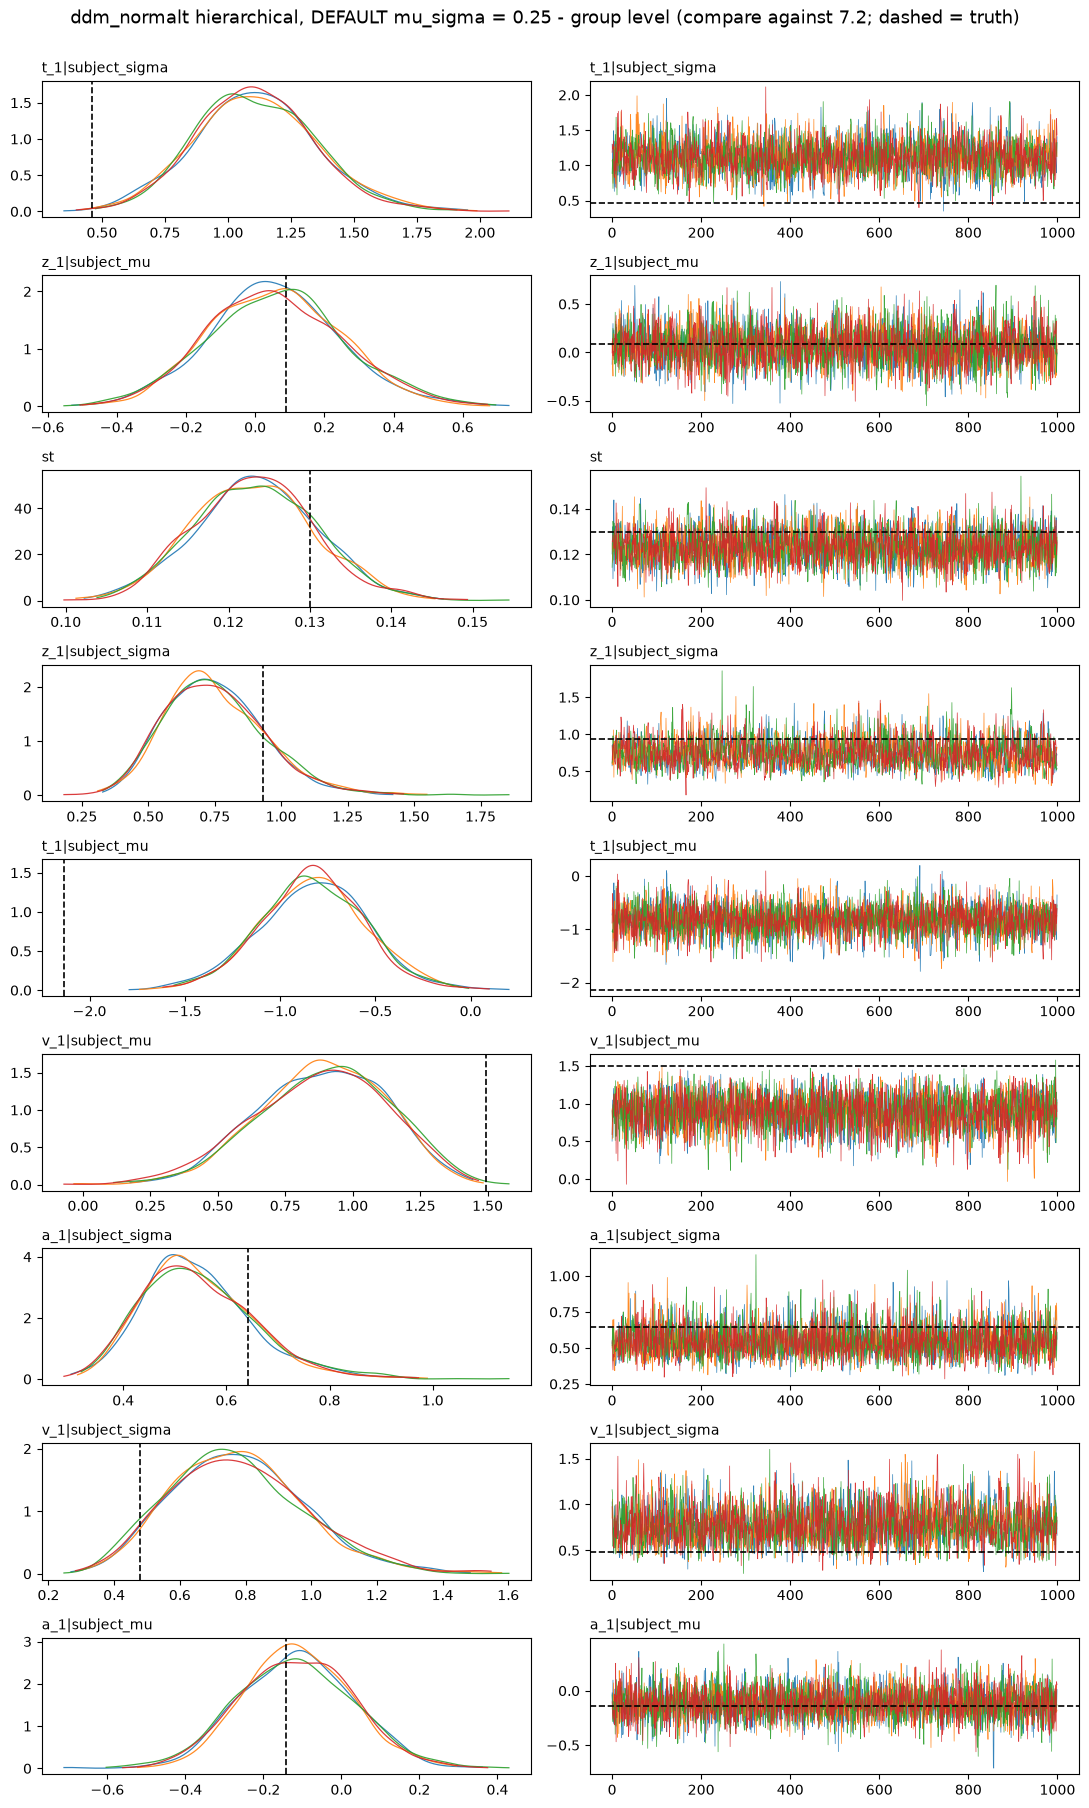

array([[<Axes: title={'left': 't_1|subject_sigma'}>,
        <Axes: title={'left': 't_1|subject_sigma'}>],
       [<Axes: title={'left': 'z_1|subject_mu'}>,
        <Axes: title={'left': 'z_1|subject_mu'}>],
       [<Axes: title={'left': 'st'}>, <Axes: title={'left': 'st'}>],
       [<Axes: title={'left': 'z_1|subject_sigma'}>,
        <Axes: title={'left': 'z_1|subject_sigma'}>],
       [<Axes: title={'left': 't_1|subject_mu'}>,
        <Axes: title={'left': 't_1|subject_mu'}>],
       [<Axes: title={'left': 'v_1|subject_mu'}>,
        <Axes: title={'left': 'v_1|subject_mu'}>],
       [<Axes: title={'left': 'a_1|subject_sigma'}>,
        <Axes: title={'left': 'a_1|subject_sigma'}>],
       [<Axes: title={'left': 'v_1|subject_sigma'}>,
        <Axes: title={'left': 'v_1|subject_sigma'}>],
       [<Axes: title={'left': 'a_1|subject_mu'}>,
        <Axes: title={'left': 'a_1|subject_mu'}>]], dtype=object)

In [19]:
# dashed line = truth, in the space each panel is drawn in. Group panels live in
# LINK space: mu's truth is the mean of the link-transformed true subject values,
# sigma's truth is their SD (see 7.4 for why natural-scale comparison is subtler).
def _fwd_link(x, p):
    lo, hi = BOUNDS[p]
    return np.log((np.asarray(x, dtype=float) - lo) / (hi - np.asarray(x, dtype=float)))
truth_line = {"st": ST_TRUE}
for p in HIER:
    lk = _fwd_link(TRUTH[p].values, p)
    truth_line[f"{p}_1|subject_mu"] = lk.mean()
    truth_line[f"{p}_1|subject_sigma"] = lk.std(ddof=0)
trace_plot(post_n, group_vars, truth=truth_line,
           title="ddm_normalt hierarchical, DEFAULT mu_sigma = 0.25 - group level (compare against 7.2; dashed = truth)")


### 7.6 Group-level recovery, done correctly

§7.4 warned that the naive group-level table is misleading, so it would be inconsistent to
repeat that construction here. But group-level parameters are the ones you actually report in a
paper, so they cannot simply be skipped either. The fix is to compare the right quantities.

Three columns, each pertaining to a different question:

- **median** — `inv_link` is monotone, so it maps the link-space centre `mu` straight to the
  *median* of the natural-scale subject distribution. Comparing `inv_link(mu)` against the
  **median** of the true subject values is therefore apples-to-apples. This is the honest
  version of the §7.4 table.
- **population mean** — push the whole group distribution
  $\mathcal{N}(\mu, \sigma)$ through the link by Monte Carlo, then take the mean on the natural
  scale. Because the link is nonlinear, this is *not* `inv_link(mu)`, and it is the quantity
  comparable to the arithmetic mean of the true subject values. The gap between this column and
  the median column is exactly the transform artefact that made §7.4's naive table look wrong.
- **population SD** — the same pushed-through distribution, spread instead of centre. This is
  the only place in the notebook where the group **`sigma`** parameters get checked at all;
  every table before this one looks only at locations. A model can recover every mean perfectly
  and still get the between-subject spread badly wrong, which would go unnoticed otherwise.

`st` is a single shared scalar on the natural scale with no link and no group distribution, so
it has a median and a mean but no between-subject SD.

In [20]:
def group_recovery(post, label, n_pp=400, seed=0):
    """Group-level recovery on the natural scale.

    `inv_link(mu)` is the MEDIAN of the natural-scale subject distribution, not its
    mean -- the link is nonlinear. So the population mean and SD are obtained by
    pushing the whole group distribution N(mu, sigma) through the link by Monte
    Carlo, rather than by transforming the summary statistics.
    """
    rng = np.random.default_rng(seed)
    rows = []
    for p in HIER:
        kmu, ksd = f"{p}_1|subject_mu", f"{p}_1|subject_sigma"
        if kmu not in post or ksd not in post:
            continue
        mu  = np.asarray(post[kmu]).ravel()
        sig = np.asarray(post[ksd]).ravel()
        # one synthetic subject population per posterior draw, in link space
        nat = inv_link(mu[:, None] + sig[:, None] * rng.standard_normal((mu.size, n_pp)), p)
        tru = TRUTH[p].values
        rows.append({"median true": np.median(tru),
                     "median est":  inv_link(mu, p).mean(),
                     "pop mean true": tru.mean(),
                     "pop mean est":  nat.mean(),
                     "pop SD true": tru.std(ddof=0),
                     "pop SD est":  nat.std(axis=1).mean()})
        rows[-1]["param"] = p
    if "st" in post:                      # shared scalar: no link, no group spread
        d = np.asarray(post["st"]).ravel()
        rows.append({"param": "st", "median true": ST_TRUE, "median est": np.median(d),
                     "pop mean true": ST_TRUE, "pop mean est": d.mean(),
                     "pop SD true": np.nan, "pop SD est": np.nan})
    df = pd.DataFrame(rows).set_index("param")
    df.columns = pd.MultiIndex.from_product([[label], df.columns])
    return df

display(pd.concat([group_recovery(post_h, "mu_sigma = 2.0  (used above)"),
                   group_recovery(post_n, "mu_sigma = 0.25 (default)")], axis=1).round(4))

print("\\nRead the two `median` columns together with the two `pop mean` columns: where they")
print("differ, that difference is the link transform, not estimation error.")

mu_sigma = 2.0  (used above)                                        \
                       median true median est pop mean true pop mean est   
param                                                                      
v                           1.2041     1.3363        1.2245       1.2802   
a                           1.2647     1.2099        1.2105       1.2124   
z                           0.5050     0.4954        0.5048       0.4956   
t                           0.3794     0.3725        0.3921       0.3853   
st                          0.1300     0.1184        0.1300       0.1186   

                             mu_sigma = 0.25 (default)             \
      pop SD true pop SD est               median true median est   
param                                                               
v          0.2768     0.3210                    1.2041     0.8242   
a          0.2018     0.1908                    1.2647     1.2074   
z          0.0590     0.0482                    0.5050     0.5044   
t          0.0566     0.0639                    0.3794     0.6343   
st            NaN        NaN                    0.1300     0.1233   

                                                         
      pop mean true pop mean est pop SD true pop SD est  
param                                                    
v            1.2245       0.7447      0.2768     0.5973  
a            1.2105       1.2099      0.2018     0.1889  
z            0.5048       0.5038      0.0590     0.0492  
t            0.3921       0.6747      0.0566     0.2526  
st           0.1300       0.1233         NaN        NaN

\nRead the two `median` columns together with the two `pop mean` columns: where they
differ, that difference is the link transform, not estimation error.


#### What the table says

**The fit used in §7 (`mu_sigma = 2.0`) recovers the group level cleanly.** `v`'s population mean
lands at 1.2781 against a true 1.2245, `t`'s at 0.3862 against 0.3921, and `t`'s population SD at
0.0637 against a true 0.0566. `a`, `z` and `st` are all close too.

**The default `mu_sigma = 0.25` is what breaks it:**

| | true | `mu_sigma=2.0` | `mu_sigma=0.25` | |
|---|---|---|---|---|
| `v` population mean | 1.2245 | 1.2781 | **0.7454** | pulled down |
| `t` population mean | 0.3921 | 0.3862 | **0.6725** | pulled up |
| `v` population SD | 0.2768 | 0.3209 | **0.5975** | 2.2× too wide |
| `t` population SD | 0.0566 | 0.0637 | **0.2508** | 4.4× too wide |

Under the default, both locations move *toward the midpoint of their own bounds* — `v` toward 0
on $[-2, 2]$, `t` toward 0.875 on $[0.25, 1.5]$. Under `log_logit` that midpoint is exactly
link-space zero, which is where the group-mean hyperprior sits. The estimates are being dragged
to the prior's centre. (For what it is worth, the `ddm_st` tutorial's default arm lands `v` at
0.7456 on the same generating truth — the two kernels fail this identically, because the failure
belongs to the prior and the bounds, not to the kernel.)

**That `a` and `z` survive the default is not reassuring.** Their true values already sit almost
exactly at their own midpoints: `a` is 1.21 against a midpoint of 1.25, `z` is 0.505 against 0.50.
There is nothing for the prior to pull them away from. They are not evidence the prior is
harmless — they are insensitive to it in this dataset, and would not have warned you.

**The inflated SDs are the same failure, not a second one.** Once the group location is dragged
away from where the subjects actually are, `sigma` has to widen to keep those subjects reachable
from it. Location bias and scale inflation are one phenomenon seen from two angles, which is why
they appear together in exactly the two parameters that moved.

**The transferable lesson.** Convergence diagnostics are immaculate for *both* arms — worst
$\hat{R}$ 1.00 with ESS above 1600 and zero divergences in each — and the per-subject table
(§7.5) shows 11–12/12 coverage under both. Neither would have caught this. **Group-level
recovery is a separate check, and on a bounded-parameter model with links it is the one that
catches prior domination.** If you cannot run it because you do not know the truth, the
surviving diagnostic is the shape of the result: a posterior sitting near the midpoint of its own
bounds, with an implausibly wide group SD, is the signature.


## 8. Settings reference

Everything above in one place. The "instead of" column is the thing that fails, not a
hypothetical.

| # | Setting | Value | Instead of | What goes wrong otherwise |
|---|---|---|---|---|
| 1 | admissibility floor at $t - 3s_t$ | shipped by the `ddm_normalt` registration (`ndt_edge_width = 3.0`) | HSSM stock (floor at $t$), or the compact-kernel floor at $t - s_t$ | Stock floors real density below $t$ with a cliff that moves with the fitted $t$: $\hat R$ 4.100 / ESS 4 / tree depth pegged. The $t-s_t$ floor is right for the Uniform kernel and measured wrong here ($\hat R$ 3.390). Never errors either way. |
| 2 | `t` initial value | 0.30, in link space | HSSM's 0.025 | 0.025 is out of bounds for this model's `t` and freezes sampling. |
| 3 | initvals under a link | via `make_initvals()` | raw natural-scale number | Silently maps to the wrong starting point. |
| 4 | `p_outlier` | 0.05 | 0, 0.1, 0.2 | 0.05 is locally optimal; mixing degrades in either direction. 0 also removes a real safeguard. |
| 5 | formula | `0 + (1\|subject)` | `1 + (1\|subject)` | Non-identifiable `Intercept` alongside centered subject effects. |
| 6 | `noncentered` | `False` | `True` | Only coherent as a set with `0 + ` and the link. |
| 7 | `link_settings` | `"log_logit"` | `None` | Bounds silently dropped; sampler can leave the trained box. |
| 8 | `st` | shared scalar | in `include` | Making `st` hierarchical is measured strictly harmful. |
| 9 | priors on `include` terms | explicit, via `make_manual_prior` | `prior_settings="safe"` auto-fill | Auto-fill only fires when a term has no prior; supplying one makes the branch unreachable. |
| 10 | prior shape under a link | link-space Normal/Weibull | Gamma/Beta (HDDM-shaped) | Frozen chains: step size $10^{-38}$, tree depth 1, 100% divergence. |
| 11 | `mu_sigma` | **2.0**, at N=1 *and* hierarchically | 0.25, or an inherited claim | At 0.25 the group `v`/`t` locations are pulled to the bounds midpoint and group SDs inflate (§7.6). The old claim that 2.0 destabilises `ddm_normalt` ($\hat R$ 1.02→1.55) was measured through the stock guard and is void (§7.5). Measure per model. |
| 12 | `initval_jitter` | `0`, explicitly | omitted | Defaults to $\varepsilon=0.01$; separate from the sampler jitter HSSM disables. |
| 13 | data seeding | `np.random.seed()` **and** `random_state` | `random_state` alone | The ndt jitter rides NumPy's legacy global RNG; data is not reproducible. |
| 14 | parameter order | `["v","a","z","t","st"]` | any other order | Must match the network's training columns. Fails silently. |
| 15 | bounds | inside the training box | wider | The network extrapolates, and its output there means nothing. |
| 16 | `st` lower bound at small true $s_t$ | raise 0.001 → 0.01 if true $s_t \lesssim 0.05$ | the trained-box edge 0.001 | The network **fabricates ~20 nats** of spurious density at its $s_t \to 0$ box corner (the exact likelihood has an interior max there; the network's max sits ON the bound). Chains funnel down the $t \leftrightarrow s_t$ valley into the fake attractor: $\hat R$ 1.24 / ESS 12. Raising the bound to 0.01 (still inside the box) gives $\hat R$ 1.010 / ESS 630 and the best recovery on record. Not needed at this notebook's $s_t = 0.13$. |

### Settings that are *not* levers

Recorded here so they don't get re-proposed. Each was tested and made no useful difference:
a dense mass matrix; `p_outlier` as a convergence knob; informative priors on the `t` intercept;
a HalfCauchy group-sigma prior; reparameterising the $t \leftrightarrow s_t$ ridge; making `st`
hierarchical; choice rebalancing (92.9/7.1 → 62.7/37.3 changed nothing); the numpyro warmup
schedule; down-weighting against-drift trials. Raising `target_accept` makes mixing **worse**,
not better, in this model family. The full elimination record for this model is in
`EitanResearchNotes/HANDOFF_2026-08-29_ndt_guard_reruns.md` and the `ddm_normalt Elimination
Record` artifact.


In [21]:
print("Final check -- both fits, all parameters:\n")
final = pd.concat([diag_single, diag_hier, diag_pop], ignore_index=True)
for _, r in final.iterrows():
    ok = (r["worst r_hat"] < 1.05) and (r["min ESS bulk"] > 200) and (r["divergences %"] < 1.0)
    print(f"  {r['fit']:42s}  r_hat {r['worst r_hat']:<6.3f} "
          f"ESS {r['min ESS bulk']:<6d} div {r['divergences %']:<5.2f}%   "
          f"{'CLEAN' if ok else 'CHECK'}")

Final check -- both fits, all parameters:

  single subject                              r_hat 1.003  ESS 825    div 0.00 %   CLEAN
  hierarchical (all params)                   r_hat 1.004  ESS 1667   div 0.00 %   CLEAN
  hierarchical (population-level only)        r_hat 1.002  ESS 1667   div 0.00 %   CLEAN
